# Planck HFI cosmic-birefringence likelihood
Precompute theory and covariance, run/resume emcee, and plot with GetDist.

In [1]:
# Run this cell immediately after restarting the kernel, before importing NumPy.
import os
for variable in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
                 'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ[variable] = '1'

%cd /global/homes/l/lonappan/workspace/cosmic_birefringence
%pip install -e . -q
from cosmic_bire import CBlike
config = 'configs/planck_hfi.yml'
# Choose backend='fortran' (OpenMP) or backend='python' (Numba).
lh = CBlike(config, backend='fortran', threads=4)
print('Likelihood backend:', lh.backend)

/global/u2/l/lonappan/workspace/cosmic_birefringence
Note: you may need to restart the kernel to use updated packages.
Likelihood backend: fortran


## Precompute
This creates or loads QuickPol-smoothed ΛCDM, ψℓ, and the reference analytic covariance.

In [2]:
analysis = lh.precompute()

Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Number of alphas: 8
Using hfi/lfi ps mask with CO. Index: 1
Importing observed cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/spectra/raw/cl_mask_percent_30_freq_100_143_217_353.npy
Importing beam smoothed LCDM cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Loading /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Loading saved covariance matrix. Filename: /global/homes/l/lonappan/pscratch/CBDATA/covariance/cov_bin_cl_hfi_mask_percent_30_100_143_217_353_lmin51_lmax1491.npy


## Sample
`resume=True` appends `nstep` samples to the existing HDF chain. Use at least 26 walkers for the current 13-dimensional model; the YAML default is 32. BLAS stays single-threaded to avoid nesting; the selected likelihood backend controls its own thread count.

In [ ]:
samples = lh.run_sampler(progress=True, resume=True)
samples.shape

Resuming /global/homes/l/lonappan/pscratch/CBDATA/chains/planck_hfi_mask_30.h5 from step 5974


 18%|█▊        | 18406/100000 [3:19:18<15:44:57,  1.44it/s]

## GetDist corner plot

Loaded 124032 samples directly from /global/homes/l/lonappan/pscratch/CBDATA/chains/planck_hfi_mask_30.h5
Removed no burn in


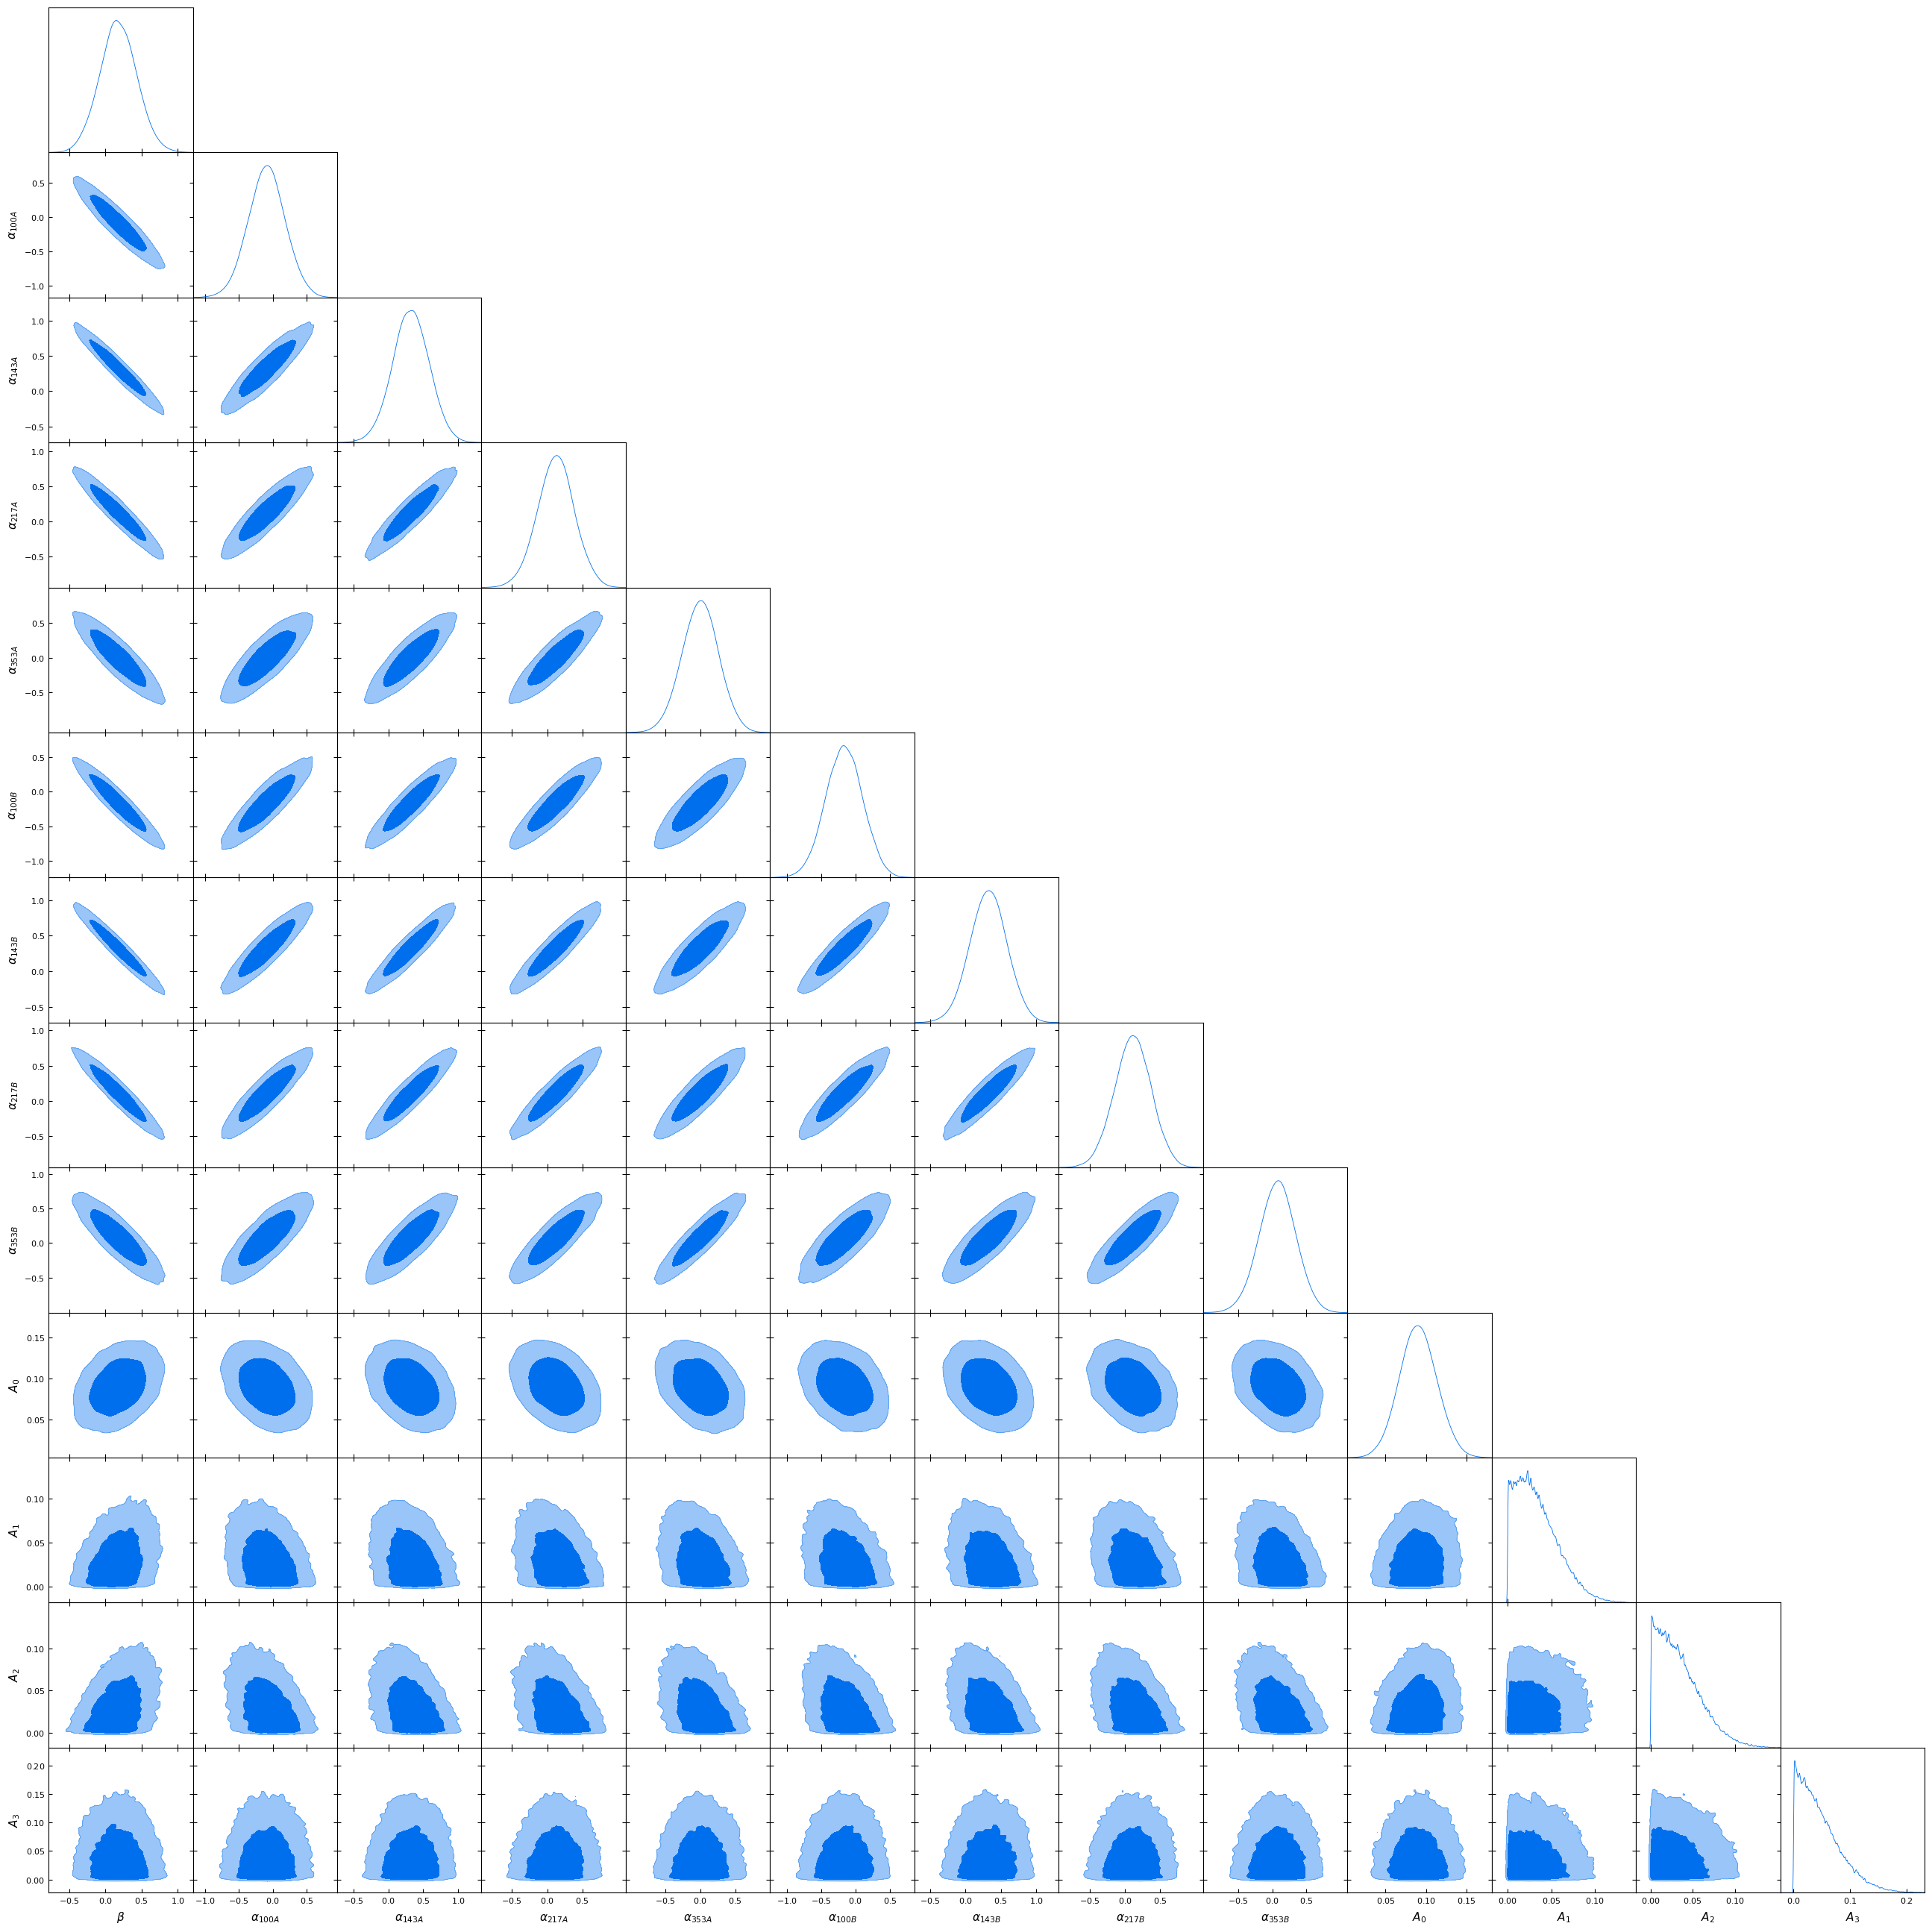

In [2]:
# Reload automatically if this kernel still holds an older CBlike definition.
import inspect
if 'show' not in inspect.signature(lh.plot_corner).parameters:
    import importlib
    import cosmic_bire.likelihood as likelihood_module
    importlib.reload(likelihood_module)
    lh = likelihood_module.CBlike(config, backend='fortran', threads=4)

corner_plot = lh.plot_corner(show=True)

In [3]:
s = lh.getdist_samples()

Removed no burn in


In [4]:
print(s.getTable(limit=1).tableTex())

\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\beta          $} & $0.18\pm 0.26              $\\

{\boldmath$\alpha_{100A}  $} & $-0.09\pm 0.27             $\\

{\boldmath$\alpha_{143A}  $} & $0.32\pm 0.26              $\\

{\boldmath$\alpha_{217A}  $} & $0.12\pm 0.26              $\\

{\boldmath$\alpha_{353A}  $} & $0.00\pm 0.27              $\\

{\boldmath$\alpha_{100B}  $} & $-0.17\pm 0.27             $\\

{\boldmath$\alpha_{143B}  $} & $0.32\pm 0.26              $\\

{\boldmath$\alpha_{217B}  $} & $0.11\pm 0.26              $\\

{\boldmath$\alpha_{353B}  $} & $0.08\pm 0.27              $\\

{\boldmath$A_{0}          $} & $0.090\pm 0.023            $\\

{\boldmath$A_{1}          $} & $0.034^{+0.010}_{-0.034}   $\\

{\boldmath$A_{2}          $} & $0.0344^{+0.0090}_{-0.034} $\\

{\boldmath$A_{3}          $} & $0.048^{+0.012}_{-0.047}   $\\
\hline
\end{tabular}
